#### Planned detection/algorithm flow
* **For point anomalies:**
telemetry data (only the first column) -> IQR and k-NN -> analyze results

* **For contextual anomalies**
telemetry data with all the features -> k-NN and LOF -> analyze results


#### First, import dataset from kaggle

In [92]:
import os
import zipfile
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
import time
from sklearn.preprocessing import MinMaxScaler

from dotenv import load_dotenv

load_dotenv()  # load .env variables into the session

True

In [ ]:
kaggle_username = os.getenv("KAGGLE_USERNAME")
kaggle_key = os.getenv("KAGGLE_KEY")

os.system("kaggle datasets download patrickfleith/nasa-anomaly-detection-dataset-smap-msl") # downloaded as zip file

with zipfile.ZipFile("nasa-anomaly-detection-dataset-smap-msl.zip", "r") as zip_ref:
    zip_ref.extractall("./data")

In [65]:
# Quick control
p_1 = np.load("data/data/data/test/E-13.npy")
print(p_1)

m_6 = np.load("data/data/data/test/M-6.npy")
print(m_6)

[[-0.6152518   0.          0.         ...  0.          0.
   0.        ]
 [-0.6542816   0.          0.         ...  0.          0.
   0.        ]
 [-0.58995124  0.          0.         ...  0.          0.
   0.        ]
 ...
 [-0.75055719  0.          0.         ...  0.          0.
   0.        ]
 [ 0.78527119  0.          0.         ...  0.          0.
   0.        ]
 [ 0.7981533   0.          0.         ...  0.          0.
   0.        ]]
[[ -1.           0.           0.         ...   0.           0.
    0.        ]
 [ -1.           0.           0.         ...   0.           0.
    0.        ]
 [ -1.           0.           0.         ...   0.           0.
    0.        ]
 ...
 [129.89189189   0.           0.         ...   0.           0.
    0.        ]
 [129.89189189   0.           0.         ...   0.           0.
    0.        ]
 [129.89189189   0.           0.         ...   0.           0.
    0.        ]]


#### Prepare the required data format
* Get channels that belong to different spacecrafts for controlling if the number of attributes is consistent across the measurements that belong to the same spacecraft  

* Get channels that have only point anomalies and the ones that contain only contextual anomalies. Later we will use this to drop the channels/measurements that contain mixed anomalies.

In [4]:
# Helper functions
import re

def parse_class(class_str):
    """Parse the given class labels from string to list"""
    # list return ediyor, stringden ayrıştırıyoruz
    return re.findall(r'point|contextual', class_str)

def parse_anomaly_sequences(sequence_str):
    """Parse the given anomaly sequence windows from string to int range list"""
    pairs = re.findall(r'\[(\d+),\s*(\d+)\]', sequence_str)
    return [[int(start), int(end)] for start, end in pairs]

In [5]:
labeled_data = pd.read_csv("data/labeled_anomalies.csv")

# parse and add properly parsed data back to the labeled_data class
labeled_data['class_parsed'] = labeled_data['class'].apply(parse_class)
labeled_data['anomaly_sequences_parsed'] = labeled_data['anomaly_sequences'].apply(parse_anomaly_sequences)

chan_and_spacecraft =  labeled_data[["chan_id" , "spacecraft"]]

msl_data = chan_and_spacecraft[chan_and_spacecraft["spacecraft"] == "MSL"]
smap_data = chan_and_spacecraft[chan_and_spacecraft["spacecraft"] == "SMAP"]

point_channels = labeled_data[labeled_data['class_parsed'].apply(lambda x: all(c == 'point' for c in x))]['chan_id'].tolist()
contextual_channels = labeled_data[labeled_data['class_parsed'].apply(lambda x: all(c == 'contextual' for c in x))]['chan_id'].tolist()

msl_channels = msl_data["chan_id"].to_list()
smap_channels = smap_data["chan_id"].to_list()

# show the first 10 channels of each class for testing purposes
print("SMAP channels: ", smap_channels[:10])
print("MSL channels: ", msl_channels[:10], "\n")

print("Point anomaly channels: ", point_channels[:10])
print("Contextual anomaly channels: ", contextual_channels[:10])

# mixed anomalies are dropped, that's why the total number of channels is now 78
print("Total num of channels: ", len(point_channels) + len(contextual_channels))

SMAP channels:  ['P-1', 'S-1', 'E-1', 'E-2', 'E-3', 'E-4', 'E-5', 'E-6', 'E-7', 'E-8']
MSL channels:  ['M-6', 'M-1', 'M-2', 'S-2', 'P-10', 'T-4', 'T-5', 'F-7', 'M-3', 'M-4'] 

Point anomaly channels:  ['S-1', 'E-2', 'E-3', 'E-4', 'E-5', 'E-6', 'E-7', 'E-8', 'E-9', 'A-1']
Contextual anomaly channels:  ['P-1', 'E-1', 'E-10', 'E-11', 'E-12', 'E-13', 'A-2', 'A-3', 'A-4', 'G-1']
Total num of channels:  78


Below code showed that the channel P-2 had 2 entries with different but very close sequences in the labeled data, so the next cell fixes that problem by merging the two windows together.

In [6]:
"""
# set the index for labeled data as channel id for further access-convenience
labeled_data = labeled_data.set_index('chan_id')

print(labeled_data.index.duplicated().sum())  # how many duplicate chan_ids?
print(labeled_data[labeled_data.index.duplicated(keep=False)]) 
"""

"\n# set the index for labeled data as channel id for further access-convenience\nlabeled_data = labeled_data.set_index('chan_id')\n\nprint(labeled_data.index.duplicated().sum())  # how many duplicate chan_ids?\nprint(labeled_data[labeled_data.index.duplicated(keep=False)]) \n"

In [7]:
# merge duplicate channels by combining their anomaly sequences
labeled_data = labeled_data.groupby('chan_id').agg({
    'spacecraft': 'first',
    'class': 'first',
    'num_values': 'first',
    'class_parsed': 'first',
    'anomaly_sequences': 'first',
    'anomaly_sequences_parsed': lambda x: [seq for seqs in x for seq in seqs]
}).reset_index()

labeled_data = labeled_data.set_index('chan_id')

Point anomalies are single values that fall within low-density regions of values, collective anomalies indicate that a sequence of values is anomalous 
rather than any single value by itself, and contextual anomalies are single values that do not fall within low-density regions yet are anomalous with 
regard to local values. (Hundman et al)


In this study i will explor point and contextual anomalies

#### Check the attribute numbers across spacecrafts 
* Expected: 55 attributes for MSL and 25 attributes for SMAP.

In [24]:
# use the smap_channels and msl_chanells to check for attribute number consistency in the data
def check_shape_and_attribute_numbers(spacecraft_channels, exp_attr_num):
    for channel in spacecraft_channels:
        dir = f"data/data/data/test/{channel}.npy"
        raw_data = np.load(dir)
        if raw_data.shape[1] != exp_attr_num: 
            print("Inconsistent attribute numbers.")
            return

    print("Consistent attribute number.")

# check the shape of each channel and attribute numbers
check_shape_and_attribute_numbers(smap_channels, 25) 
check_shape_and_attribute_numbers(msl_channels, 55)
        

Consistent attribute number.
Consistent attribute number.


#### Visualize the data

* Based on the num_values attribute in the labeled_anomalies.csv file, it is found out that the data in the /data/test directory are the full-length telemetry data, where /data/train directory are only parts that are seperated for training for deep-learning-based approaches. So I will be using the data in the /data/test directory.
* Below code plots all the measurements, grouping them based on their anomaly types.

    (The cell output has been cleared since the plots are quite large. The plotted graphs can be found under <code>contextual_anomaly_channels_overview.png</code> and <code>point_anomaly_channels_overview.png</code>)

In [ ]:
import matplotlib.patches as mpatches

def plot_channels_by_class(channels, class_name, labeled_data):
    """
    Plots the sensor reading (column 0) for each channel.
    Highlights anomalous regions in red using ground truth labels.
    Channels are grouped by anomaly class (point or contextual).
    """
    n_channels = len(channels)
    fig, axes = plt.subplots(n_channels, 1, figsize=(15, n_channels * 2))
    fig.suptitle(f"{class_name.capitalize()} Anomaly Channels — Sensor Readings", 
                 fontsize=14, fontweight='bold', y=1.01)
    
    for i, channel in enumerate(channels):
        raw_data = np.load(f"data/data/data/test/{channel}.npy")
        sensor_reading = raw_data[:, 0]
        
        ax = axes[i] if n_channels > 1 else axes
        
        ax.plot(sensor_reading, color='steelblue', linewidth=0.8, label='Sensor Reading')
        
        anomaly_sequences = labeled_data.loc[channel, 'anomaly_sequences_parsed']

        if isinstance(anomaly_sequences[0], int):
            anomaly_sequences = [anomaly_sequences]

        for i_seq, (start, end) in enumerate(anomaly_sequences):
            ax.axvspan(start, end, alpha=0.3, color='red', 
                    label='Anomaly' if i_seq == 0 else None)
        
        ax.set_ylabel(channel, fontsize=8, rotation=0, labelpad=40)
        ax.set_xlim(0, len(sensor_reading))
        ax.tick_params(axis='both', labelsize=7)
        ax.grid(True, alpha=0.3)
    
    normal_patch = mpatches.Patch(color='steelblue', label='Normal')
    anomaly_patch = mpatches.Patch(color='red', alpha=0.3, label='Anomaly')
    fig.legend(handles=[normal_patch, anomaly_patch], loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f"{class_name}_anomaly_channels_overview.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved as {class_name}_anomaly_channels_overview.png")


plot_channels_by_class(point_channels, "point", labeled_data)
plot_channels_by_class(contextual_channels, "contextual", labeled_data)

In [196]:
# helper funciton to plot only single channels for simple visualization and understanding.

def plot_channel_reading(chan: str, title: str):
    raw_data = np.load(f"data/data/data/test/{chan}.npy")
    sensor_reading = raw_data[:, 0]

    plt.figure(figsize=(7, 4))
    plt.plot(sensor_reading, color='steelblue', linewidth=0.8, label='Sensor Reading')

    anomaly_sequences = labeled_data.loc[chan, 'anomaly_sequences_parsed']
    
    # handle single sequence case
    if isinstance(anomaly_sequences[0], int):
        anomaly_sequences = [anomaly_sequences]

    for i, (start, end) in enumerate(anomaly_sequences):
        plt.axvspan(start, end, alpha=0.3, color='red', 
                   label='Anomaly' if i == 0 else None)

    plt.xlabel("Time Step")
    plt.ylabel("Measured Telemetry Data")
    plt.title(title + " " + f"({chan})")
    plt.legend()
    plt.show()

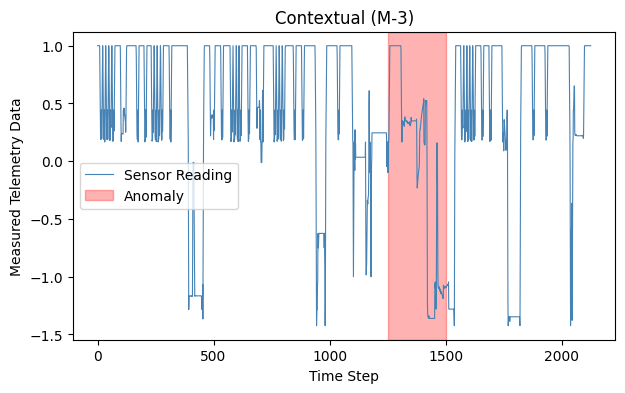

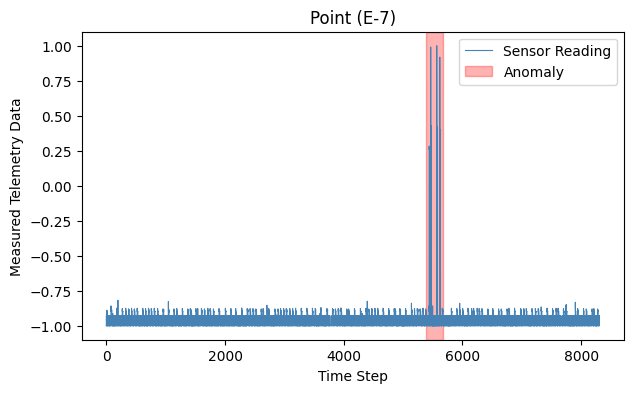

In [197]:
# Quick visualization for one point and one contextual anomaly channel.
plot_channel_reading("M-3", "Contextual")
plot_channel_reading("E-7", "Point")

#### Required parameters calculation:
* Before running the anomaly detection algorithms, we need to calculate some metrics/parameters that will be used in our anomaly detection algorithms.
* The metrics and where we will use them:

    - `anomaly_rate_contextual` and `anomaly_rate_point`are the ratio of the number of the anomalous timesteps to the non-anomalous timesteps. Initial thought was to use these values for for calculating the threshold for anomalies. But both point and contextual timesteps have found to be ~13% of the total telemetry measures (making the threshold 87%, which is low). So a default value of 99% will be used as a fixed threshold value for reducing the flagged telemetry measures.

    - `gap_threshold_point` and `gap_threshold_contextual` are thresholds that will be used as the gap when combining the detected anomalies into windows. The gap-size calculation logic is furhter below. 


In [59]:
# anomaly rates calculations
def calc_anomaly_rates(labeled_data, anom_class):
    total_timesteps = 0
    anomalous_timesteps = 0

    for channel in anom_class:    
        anomaly_sequences = labeled_data.loc[channel, 'anomaly_sequences_parsed']
        timesteps = labeled_data.loc[channel, 'num_values']

        total_timesteps += timesteps
        for s, e in anomaly_sequences:
            anomalous = e-s+1
            anomalous_timesteps += anomalous
    
    # return the rate of anomalous timesteps
    return int(anomalous_timesteps)/int(total_timesteps)


In [60]:
point_anomaly_rate = calc_anomaly_rates(labeled_data, point_channels)
contextual_anomaly_rate = calc_anomaly_rates(labeled_data, contextual_channels)

print(f"Point anomaly rate: {point_anomaly_rate}")
print(f"Contextual anomaly rate: {contextual_anomaly_rate}")

Point anomaly rate: 0.13001558465725385
Contextual anomaly rate: 0.1320447409733124


Since there are various-length gaps between the sequences, an appropriate gap threshold should be set for window merging. The proposed way to calculate it is to use the median gap value of the anomaly sequences of the same anomaly class. 

All the channels will be evaluated together, so the default gap threshold value will be consistent across the channels of same anomaly class type and won't be finetuned to best fit channels individualy.

In [61]:
def calc_med_gap(labeled_data, anom_class):
    gaps = []
    for channel in anom_class:    
        anomaly_sequences = labeled_data.loc[channel, 'anomaly_sequences_parsed']
        for s, e in anomaly_sequences:
            gap = e-s
            gaps.append(gap)

    return np.mean(gaps), np.min(gaps), np.max(gaps), np.median(gaps)

In [118]:
_, _, _, gap_threshold_point = calc_med_gap(labeled_data, point_channels)
_, _, _, gap_threshold_contextual = calc_med_gap(labeled_data, contextual_channels)
print(f"Median gap of point anomalies: {int(gap_threshold_point)}")
print(f"Median gap of contextual anomalies: {int(gap_threshold_contextual)}")

Median gap of point anomalies: 130
Median gap of contextual anomalies: 192


The calculated median gap values will be used for window merging.

In [115]:
# Function that merges nearby anomalies into windows based on the set gap_threshold
def merge_to_windows(predicted_labels, gap_threshold):
    """Merge nearby flagged timesteps into windows"""
    
    predicted_labels = np.atleast_1d(np.asarray(predicted_labels))

    anomaly_timesteps = np.where(predicted_labels == 1)[0]
    if len(anomaly_timesteps) == 0:
        return []
    windows = []
    start = anomaly_timesteps[0]
    end = anomaly_timesteps[0]
    for t in anomaly_timesteps[1:]:
        if t - end <= gap_threshold:
            end = t
        else:
            windows.append([int(start), int(end)])
            start = t
            end = t
    windows.append([int(start), int(end)]) 
    return windows

In [93]:
# check if the said scaling is done properly
for channel in point_channels + contextual_channels:
    data = np.load(f"data/data/data/test/{channel}.npy")
    col0_min = data[:, 0].min()
    col0_max = data[:, 0].max()
    if col0_min < -1.01 or col0_max > 1.01:
        print(f"{channel}: min={col0_min:.3f}, max={col0_max:.3f}  ← OUT OF RANGE")

M-6: min=-1.000, max=258.108  ← OUT OF RANGE
F-4: min=-1.000, max=1.465  ← OUT OF RANGE
F-5: min=-1.077, max=6.954  ← OUT OF RANGE
D-15: min=-1.000, max=1.376  ← OUT OF RANGE
M-1: min=-1.076, max=2.269  ← OUT OF RANGE
M-2: min=-1.085, max=1.335  ← OUT OF RANGE
M-3: min=-1.424, max=1.000  ← OUT OF RANGE
M-4: min=-1.331, max=1.176  ← OUT OF RANGE
M-5: min=-1.309, max=1.095  ← OUT OF RANGE
T-8: min=-1.000, max=1.020  ← OUT OF RANGE
F-8: min=-1.000, max=1.304  ← OUT OF RANGE


### 1. POINT ANOMALIES

Below, we define the methods that will be used to detect the point anomalies. Point anomalies are detected by considering only the first column i.e. the telemetry values of the data.

In [ ]:
# IQR calculation
def IQR_calc(data):
    start_time = time.time()

    # take only the telemetry measurements.
    X = data[:, 0]

    Q1 = np.percentile(X, 25)
    Q3 = np.percentile(X, 75)
    IQR = Q3-Q1

    lower_bound = Q1 - 1.5*IQR
    higher_bound = Q3 + 1.5*IQR

    predicted_labels = ((X < lower_bound) | (X > higher_bound)).astype(int)
    total_time = time.time() - start_time

    # hangi indexte outlier olduğunu çıkarıyoruz
    outlier_timesteps = (np.where(predicted_labels == 1)[0]).tolist()

    results = {
        'total_time': total_time,
        'is_outlier': predicted_labels,
        'outlier_timesteps' : outlier_timesteps
    }

    return results

test the IQR method for a single channel first and also test the k-nn evaluation for univariate calculation (k-nn method is defined under the contextual anomalies)

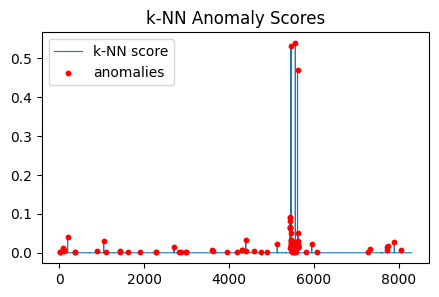

Runtime: 0.153s
Outliers detected: 89
40
[195, 5440, 5441, 5442, 5443, 5444, 5445, 5465, 5466, 5467, 5468, 5469, 5470, 5471, 5472, 5473, 5474, 5475, 5567, 5568, 5569, 5570, 5571, 5572, 5573, 5574, 5575, 5576, 5577, 5618, 5619, 5620, 5621, 5622, 5623, 5624, 5625, 5626, 5627, 5628]
89
[11, 22, 79, 107, 108, 195, 380, 381, 877, 1046, 1096, 1435, 1436, 1614, 1906, 2281, 2291, 2705, 2830, 2871, 2992, 2994, 3598, 3616, 3954, 4185, 4309, 4310, 4395, 4397, 4584, 4745, 4887, 5141, 5437, 5440, 5441, 5442, 5443, 5444, 5445, 5465, 5466, 5467, 5468, 5469, 5470, 5471, 5472, 5473, 5474, 5475, 5495, 5497, 5526, 5537, 5567, 5568, 5569, 5570, 5571, 5572, 5573, 5574, 5575, 5576, 5577, 5590, 5618, 5619, 5620, 5621, 5622, 5623, 5624, 5625, 5626, 5627, 5628, 5810, 5953, 6080, 7289, 7327, 7737, 7738, 7749, 7902, 8049]


In [151]:
e_7 = np.load("data/data/data/test/E-7.npy")
results_IQR = IQR_calc(e_7)
results_kNN = k_NN_calc(e_7, False, num_neighbors=20)

print(len(results_IQR["outlier_timesteps"]))
print(results_IQR["outlier_timesteps"])

print(len(results_kNN["outlier_timesteps"]))
print(results_kNN["outlier_timesteps"])

### 2. CONTEXTUAL ANOMALIES

k-NN and LOF are utilized for contextual anomaly detection since contextual anomaly detection will be conducted via multivariate analysis.

The attributes of the raw data are already one-hot encoded and the telemetry measures are pre-scaled between (-1,1). So we can directly use the data as-is.

In [189]:
# helper funcitons

# distance score'u verinin %99'undan fazla olanlar anomaly olarak etiketleniyor
def scores_to_labels(scores, threshold_percentile=99):
    """Converts anomaly scores to binary labels 1-outlier, 0-not"""
    threshold = np.percentile(scores, threshold_percentile)
    return (scores >= threshold).astype(int), (np.where(scores >= threshold)[0]).tolist()

def scale_first_column(data):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    data[:, 0] = scaler.fit_transform(data[:, 0].reshape(-1,1)).flatten()
    return data

def plot_detected_anomalies(scores, timesteps, method: str):
    plt.figure(figsize=(5, 3))
    plt.plot(scores, label="k-NN score", linewidth=0.8)
    plt.scatter(timesteps, scores[timesteps], color='red', s=10, zorder=5, label="anomalies")
    plt.legend()
    plt.title(f"{method} Anomaly Scores")
    plt.show()

#### k-NN

In the official explanation of the dataset, the telemetry values are told to be scaled between (-1,1) but some of the channels are not properly scaled. Therefore for better evaluation, the telemtery values are scaled between (0,1) using minmax scaler.

In [210]:
# k-NN
def k_NN_calc(data, is_multivariate: bool, num_neighbors):
    start = time.time()
    
    X = data.copy()
    
    # scale telemetry column
    X = scale_first_column(X)

    if is_multivariate:
        # ilk sütun kendisi olduğu için onu exclude ederiz, total neighbor sayısını da bundan dolayı 1 fazla alırız
        # .fit(X) yaptığımızda NearestNeigbors internal olarak algoritmayı ve nasıl hesaplayacağını belirler, indexleme yapar.
        nbrs = NearestNeighbors(n_neighbors=num_neighbors + 1).fit(X)

        # distances.shape() = (N,k+1) olacak şekilde her N noktasının k+1 tane komşusunun indexini tutar.
        distances, _ = nbrs.kneighbors(X)

        # ilk sütunu dropluyoruz- kendisine olan uzaklıkları dahil etmemek için.
        distances = distances[:, 1:]
    else:
        # univariate version point anomalies için. burada contextual veri kullanılmayacak o yüzden sadece telemetry ölçümüne bakıyoruz
        X_uni = X[:, 0].reshape(-1, 1)
        nbrs = NearestNeighbors(n_neighbors=num_neighbors + 1).fit(X_uni)
        distances, _ = nbrs.kneighbors(X_uni)
        distances = distances[:, 1:]  # exclude self-distance
        
    # calcualte the mean distance of each point from its neighbors
    scores = distances.mean(axis=1) 
    labels, timesteps = scores_to_labels(scores) # label the highest distances as anomalies.

    runtime = time.time() - start
    #print(f"Runtime: {runtime:.3f}s")
    #print(f"Outliers detected: {len(timesteps)}")
    
    # simple visualization
    #plot_detected_anomalies(scores, timesteps, "k-NN")

    results = {
            'total_time': runtime,
            'is_outlier': labels,
            'outlier_timesteps' : timesteps
        }
    return results
    

Test with one example

Runtime: 0.043s
Outliers detected: 54


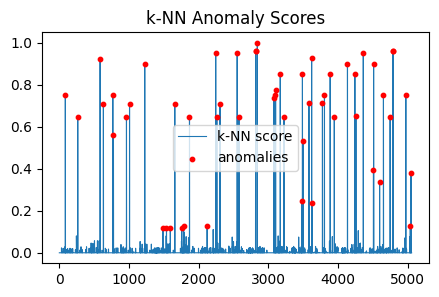

Anomaly sequences merged to windows: [[86, 264], [585, 1007], [1225, 1225], [1486, 1867], [2120, 2304], [2551, 2576], [2815, 2840], [3074, 3223], [3476, 5045]]


In [191]:
f_7 = np.load("data/data/data/test/F-7.npy")

results_kNN = k_NN_calc(f_7, True, num_neighbors=20)
windows = merge_to_windows(results_kNN['is_outlier'], gap_threshold_contextual)
print(f"Anomaly sequences merged to windows: {windows}")
# [1250, 1450], [2670, 2790], [3325, 3425]

#### LOF

In [211]:
# define the LOF function. (bunu da farklı k değerleri ile deneyebiliriz. k-NN ve LOF için kullanılan k değerinin tablolaması yapılabilir.)
def LOF_calc(data, num_neighbors):
    start = time.time()

    X = data.copy()
    X = scale_first_column(X) # scale the first column again. 

    lof = LocalOutlierFactor(n_neighbors=num_neighbors)
    lof.fit_predict(X) # this returns only 1 or -1 based on internal labeling

    # the actual lof values are stored in another varible named "negative_outlier_factor_" negatively we access it 
    lof_scores = -lof.negative_outlier_factor_
    labels, timesteps = scores_to_labels(lof_scores)

    lof_time = time.time() - start

    # simple visualization
    #plot_detected_anomalies(lof_scores, timesteps, "LOF")
    #print(f"Runtime: {lof_time:.3f}s")
    #print(f"Outliers detected: {len(timesteps)}")

    results = {
        'total_time': lof_time,
        'is_outlier': labels,
        'outlier_timesteps': timesteps
    }
    
    return results

Try for a data point.

/Users/serra/Documents/TOBB ETU CS/Spring 2026/BİL 476/anomaly-detection-and-characterization-in-nasa-telemetry-data/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


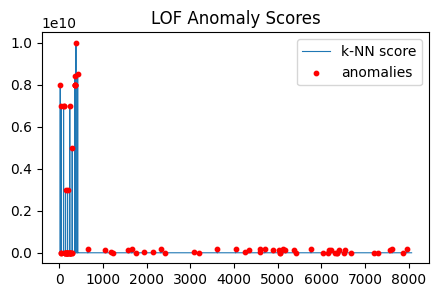

Runtime: 0.067s
Outliers detected: 82
Anomaly sequences merged to windows: [[21, 420], [653, 653], [1056, 1220], [1579, 1757], [1950, 1950], [2147, 2413], [3074, 3190], [3620, 3620], [4037, 4037], [4261, 4338], [4593, 5179], [5375, 5425], [5765, 5765], [6037, 6682], [7197, 7304], [7567, 7632], [7872, 7955]]


In [194]:
p_7 = np.load("data/data/data/test/P-7.npy")

results_lof = LOF_calc(p_7, 20)
windows = merge_to_windows(results_lof['is_outlier'], gap_threshold_contextual)
print(f"Anomaly sequences merged to windows: {windows}")